# Final Analysis for 1mio events

### Data
1. low min_thresh=-0.002 for sig and bkg saved under all*lowthresh.npy
2. jitter deltas saved under all_deltas.npy with min_thresh=-0.02

### Tasks:
1. rewriting older functions for loop compatibility
2. loop over the 200 or so acquisitions inside of the directory
3. save metadata inside of the histograms and add up $\rightarrow$ decide for binning based on signal file? on first? or select maximum from all of them? binning isn't really adaptable if I want to save in array

In [50]:
import pandas as pd
import numpy as np
import scipy as sp
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import csv
import pyarrow as pa 
import RS_RTxReadBin as rb  
from RS_RTxReadBin.RTxReadBin import RTxReadBin  
import os 
from scipy.optimize import curve_fit
from pathlib import Path

In [51]:
from functions_singledata import converter_binary_to_df
from functions_singledata import plot_all_channels
from functions_singledata import main_ratio_and_plots
from functions_singledata import main_amplitude_spectrum

## Amplitude Code

In [3]:
path_sig = Path('/Users/laloscola/ExternalDrive/1mio_events_sig/')
files_sig = list(path_sig.glob('Run_*.Wfm.bin'))
count_sig = len(files_sig)
print(f'There are {count_sig} signal files')

There are 0 signal files


In [52]:
dx = 0.5e-12 # max resolution was 1e-12 (area can still have non-integer values) --- adapt such that selecting the number of bins autosets dx
bin_edges_jitter = np.arange(-15e-9, 15e-9 + dx, dx) # this would give 10000 bins
bin_edges_ampl = np.arange(0, 1e-10 +dx, dx)

In [53]:
counts_total_jitter = np.zeros(len(bin_edges_jitter) - 1, dtype=np.int64)
counts_total_ampl = np.zeros(len(bin_edges_ampl) - 1, dtype=np.int64)

#### Code that sums over histograms (bad code)

In [ ]:
# saving directly in histogram code
for file_path_sig in sorted(files[0:3]): # looping over first 3 files now
    print(file_path_sig)
    df = converter_binary_to_df(file_path_sig, show_info=False)
    # main_ratio_and_plots(df, min_thresh=-0.01, show_only_camera=False)
    values_ampl = main_amplitude_spectrum(df, bins=200, show_plots=False)
    counts, _ = np.histogram(values_ampl, bins=bin_edges_ampl)
    counts_total_ampl += counts

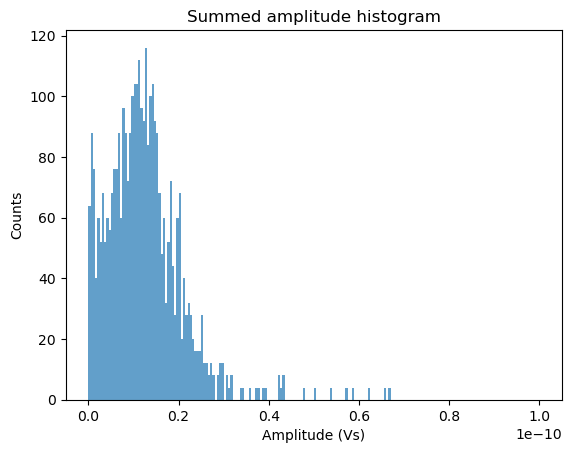

In [21]:
bin_left = bin_edges_ampl[:-1]
bin_width = np.diff(bin_edges_ampl)

plt.figure()
plt.bar(bin_left, counts_total_ampl, width=bin_width, align="edge", alpha=0.7)
plt.xlabel(f"Amplitude (Vs)")
plt.ylabel("Counts")
plt.title("Summed amplitude histogram")
plt.show()

#### Code that computes counts first and makes histograms later

In [ ]:
all_ampl_sig = []
for file_path_sig in sorted(files_sig): # looping over first 3 files now
    print(file_path_sig)
    df = converter_binary_to_df(file_path_sig, show_info=False)
    # main_ratio_and_plots(df, min_thresh=-0.01, show_only_camera=False)
    values_ampl = main_amplitude_spectrum(df, min_thresh=-0.002 ,show_plots=False)
    all_ampl_sig.append(np.asarray(values_ampl))

all_ampl_sig = np.concatenate(all_ampl_sig)

$\rightarrow$ saved all_ampl_sig under sig_amplitudes.npy

In [ ]:
bin_left = bin_edges_ampl[:-1]
bin_width = np.diff(bin_edges_ampl)

plt.figure()
plt.style.use('ggplot')
plt.hist(all_ampl_sig, bins=bin_left, color='blue', alpha=0.7)
plt.xlabel(f"Amplitude (Vs)")
plt.ylabel("Counts")
plt.title("Total amplitudes with Signal at thresh=-0.002 for 1mio events")
plt.show()

In [5]:
path_bkg = Path('/Users/laloscola/ExternalDrive/1mio_events_bkg/')
files_bkg = list(path_bkg.glob('Run_*.Wfm.bin'))
count_bkg = len(files_bkg)
print(f'There are {count_bkg} background files')

There are 100 background files


In [ ]:
all_ampl_bkg = []
for file_path_bkg in sorted(files_bkg): # looping over first 3 files now
    print(file_path_bkg)
    df = converter_binary_to_df(file_path_bkg, show_info=False)
    # main_ratio_and_plots(df, min_thresh=-0.01, show_only_camera=False)
    values_ampl = main_amplitude_spectrum(df, min_thresh=-0.002 ,show_plots=False)
    all_ampl_bkg.append(np.asarray(values_ampl))

all_ampl_bkg = np.concatenate(all_ampl_bkg)

$\rightarrow$ saved all_ampl_bkg under bkg_amplitudes.npy

In [ ]:
plt.figure()
plt.style.use('ggplot')
plt.hist(all_ampl_bkg, bins='auto', color='orange', alpha=0.7)
plt.xlabel(f"Amplitude (Vs)")
plt.ylabel("Counts")
plt.title("Total amplitude of the Background at thresh=-0.002 for 1mio events")
plt.show()

### Now analysis (calculation done above)
-> calculated data has been saved as np.array

19403 35719


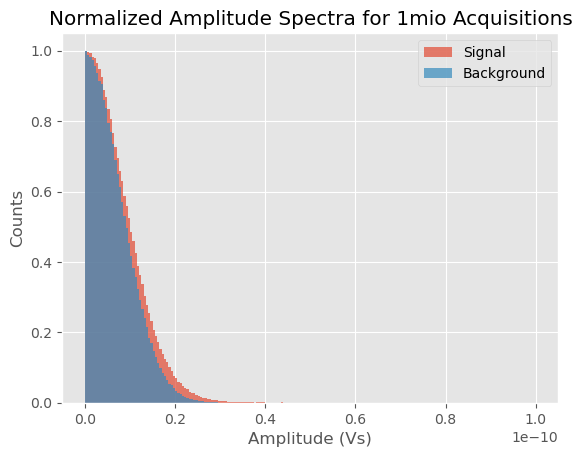

In [68]:
all_ampl_sig = np.load('sig_amplitudes_lowthresh.npy')
all_ampl_bkg = np.load('bkg_amplitudes_lowthresh.npy')

bin_left = bin_edges_ampl[:-1]
bin_width = np.diff(bin_edges_ampl)

plt.figure()
plt.style.use('ggplot')
S, edges_s = np.histogram(all_ampl_sig, bins=bin_edges_ampl) # looses the 1e-11
B, edges_b = np.histogram(all_ampl_bkg, bins=bin_edges_ampl)
Nb = max(np.histogram(all_ampl_bkg, bins=bin_edges_ampl)[0])
Ns = max(np.histogram(all_ampl_sig, bins=bin_edges_ampl)[0]) # needed for normalisation -> S - N_S/N_B * B
print(Nb, Ns)
#plt.stairs(S/Ns, edges_s, alpha=1, label='Signal')
#plt.stairs(B/Nb, edges_b, alpha=1, label='Background')
plt.bar(bin_left, S/Ns, width=bin_width, align='edge', color='C0', alpha=0.7, label='Signal')
plt.bar(bin_left, B/Nb, width=bin_width, align='edge', color='C1', alpha=0.7, label='Background')

plt.xlabel(f"Amplitude (Vs)")
plt.ylabel("Counts")
plt.legend()
plt.title("Normalized Amplitude Spectra for 1mio Acquisitions")
plt.savefig("amplitude_both_hist.png", dpi=300, bbox_inches="tight")

plt.show()

19403 35719
only positive values in Sig - Bkg


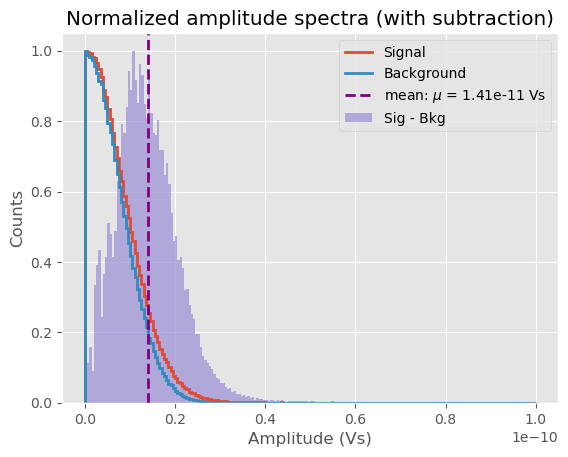

In [56]:
all_ampl_sig = np.load('all_sig_amplitudes_lowthresh.npy')
all_ampl_bkg = np.load('all_bkg_amplitudes_lowthresh.npy')

bin_left = bin_edges_ampl[:-1]
bin_width = np.diff(bin_edges_ampl)

plt.figure()
plt.style.use('ggplot')

S, edges = np.histogram(all_ampl_sig, bins=bin_edges_ampl) # looses the 1e-11
B, edges = np.histogram(all_ampl_bkg, bins=bin_edges_ampl)

# ------------------ calculations ---------------
Nb = max(np.histogram(all_ampl_bkg, bins=bin_edges_ampl)[0])
Ns = max(np.histogram(all_ampl_sig, bins=bin_edges_ampl)[0]) # needed for normalisation -> S - N_S/N_B * B

print(Nb, Ns)

S_sub = S/Ns - (1/Nb) * B
S_sub = S_sub/max(S_sub)

centers = 0.5 * (edges[:-1] + edges[1:])
mu = np.average(centers, weights=S_sub)

if not S_sub.any() < 0:
    print('only positive values in Sig - Bkg')
# --------------------- plots -----------------
plt.bar(bin_left, S_sub, width=bin_width, align='edge', label='Sig - Bkg', color='C2', alpha=0.7) #np.arange(0,2000,40))

plt.stairs(S/Ns, edges, label='Signal', color='C0', linewidth=2)
plt.stairs(B/Nb, edges, label='Background', color='C1', linewidth=2)
#plt.bar(bin_left, S/Ns, width=bin_width, align='edge', color='C0', alpha=0.4, label='Signal')
#plt.bar(bin_left, B/Nb, width=bin_width, align='edge', color='C1', alpha=0.4, label='Background')
plt.axvline(mu, color="purple", linestyle="--", linewidth=2,  label=fr'mean: $\mu$ = {mu:.3g} Vs')   

# put text in axes coordinates (0..1), so it stays in the corner when you zoom

plt.xlabel("Amplitude (Vs)")
plt.ylabel("Counts")
plt.title("Normalized amplitude spectra (with subtraction)")
plt.legend()
plt.savefig("amplitude_subtracted_hist.png", dpi=300, bbox_inches="tight")
plt.show()

final idea:
- plot S with min_thresh=-0.002
- plot B with min_thresh=-0.002
- plot S_sub as S with min_thresh=-0.01 instead of S_sub= S - k*B

### Jitter Code

In [3]:
from functions_singledata import converter_binary_to_df
from functions_singledata import main_jitter_plot_and_fwhm

In [37]:
import functions_singledata as my_fcts
import importlib

In [4]:
path_sig = Path('/Users/laloscola/ExternalDrive/1mio_events_sig/')
files_sig = list(path_sig.glob('Run_*.Wfm.bin'))
count_sig = len(files_sig)
print(f'There are {count_sig} signal files')

There are 200 signal files


In [5]:
all_deltas =  []
for file_path_sig in sorted(files_sig):
    print(file_path_sig)
    df = converter_binary_to_df(file_path_sig, show_info=False)

    deltas, mean_offset, jitter = main_jitter_plot_and_fwhm(df, min_thresh=-0.02, show_plots=False)
    print(len(deltas))
    all_deltas.append(np.asarray(deltas))
all_deltas =  np.concatenate(all_deltas)

Found multichannel File, with channels: 1, 2. Using these!


/Users/laloscola/ExternalDrive/1mio_events_sig/Run_000.Wfm.bin


Found multichannel File, with channels: 1, 2. Using these!


62
/Users/laloscola/ExternalDrive/1mio_events_sig/Run_001.Wfm.bin


Found multichannel File, with channels: 1, 2. Using these!


...

85
/Users/laloscola/ExternalDrive/1mio_events_sig/Run_197.Wfm.bin


Found multichannel File, with channels: 1, 2. Using these!


79
/Users/laloscola/ExternalDrive/1mio_events_sig/Run_198.Wfm.bin


Found multichannel File, with channels: 1, 2. Using these!


82
/Users/laloscola/ExternalDrive/1mio_events_sig/Run_199.Wfm.bin
81


In [21]:
np.save('all_deltas.npy', all_deltas)

In [6]:
from functions_singledata import plot_jitter_histogram
from functions_singledata import plot_jitter_gaussian_two_views

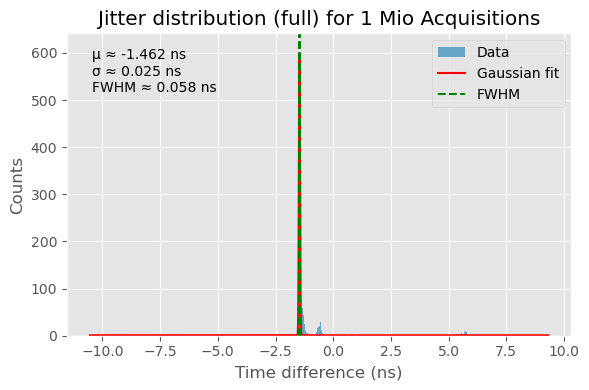

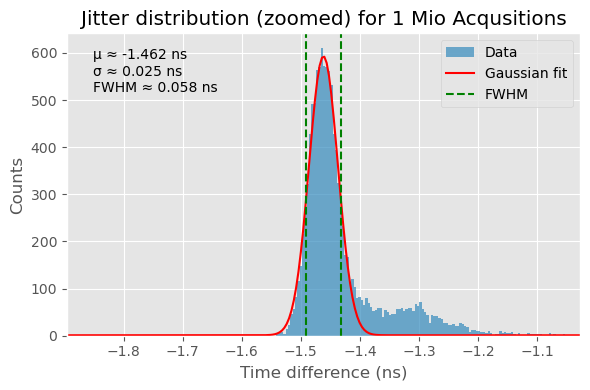

(np.float64(-1.461761283398091e-09),
 np.float64(2.4597369820078024e-11),
 np.float64(5.7922379507359044e-11))

In [58]:
importlib.reload(my_fcts)
my_fcts.plot_jitter_gaussian_two_views(all_deltas, bins=5000, save_full_fig=True, save_zoomed_fig=True, zoom_factor=15)